In [42]:
import os
import re
import urllib.parse as up

import pandas as pd
import requests

n_workers = min(6, os.cpu_count() - 1)

SAFE_CHARS = "-._~:/?#[]@!$&'()*+,;=%"
ALLOWED = set("abcdefghijklmnopqrstuvwxyz0123456789" + SAFE_CHARS)


def canonical_redirect(url, timeout=3):
    try:
        r = requests.head(url, allow_redirects=True, timeout=timeout)
        return r.url.lower()
    except requests.RequestException:
        return url.lower()


def clean_url(raw: str) -> str:
    raw = raw.strip()
    if not re.match(r'^[a-z]+://', raw):
        raw = "http://" + raw

    u = up.unquote(raw).lower()

    u = re.sub(r'^(https?://)www\.', r'\1', u)

    u = re.sub(r':(80|443)(?=/)', '', u)

    # u = canonical_redirect(u, timeout=10)

    if u.endswith('/') and u.count('/') > 2:
        u = u[:-1]

    u = ''.join(c if c in ALLOWED else '_' for c in u)

    return u

In [43]:
email_df = pd.read_csv("dataset/urls/new_data_urls.csv")

In [44]:
email_df['label'] = 1 - email_df['status']

In [45]:
email_df.drop_duplicates(['url'], inplace=True)
email_df_legitime = email_df[email_df['label'] == 0].head(50_000)
email_df_phishing = email_df[email_df['label'] == 1].head(50_000)

# email_df_legitime = email_df_legitime.head(email_df_phishing.shape[0])

# print(email_df_phishing.shape, email_df_legitime.shape)

email_df = pd.concat([email_df_legitime, email_df_phishing], ignore_index=True)
# email_df

In [46]:
from joblib import Parallel, delayed

cleaned_urls = Parallel(n_jobs=n_workers, backend="loky", verbose=2)(
    delayed(clean_url)(txt) for txt in email_df["url"]
)
email_df["url"] = cleaned_urls

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done  56 tasks      | elapsed:    0.2s
[Parallel(n_jobs=6)]: Done 73716 tasks      | elapsed:    0.5s
[Parallel(n_jobs=6)]: Done 100000 out of 100000 | elapsed:    0.6s finished


In [47]:
email_df = email_df.drop_duplicates(subset=['url'])
# email_df

In [48]:
import json

CHARS = list("abcdefghijklmnopqrstuvwxyz0123456789-._~:/?#[]@!$&'()*+,;=%")
PAD, UNK = 0, 1
char2idx = {c: i + 2 for i, c in enumerate(CHARS)}
MAX_LEN = 200

import torch


def encode_url(url: str) -> torch.Tensor:
    ids = [char2idx.get(c, UNK) for c in url[:MAX_LEN]]
    return torch.tensor(ids + [PAD] * (MAX_LEN - len(ids)))


with open("char_vocab.json", "w") as fw:
    json.dump(char2idx, fw, ensure_ascii=False, indent=2)

In [49]:
encoded = Parallel(n_jobs=n_workers, backend="loky", verbose=2)(
    delayed(encode_url)(txt) for txt in email_df["url"]
)
email_df["encoded"] = encoded

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
/home/calin/Licenta/Proiect/Phishing_Models/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[Parallel(n_jobs=6)]: Done  29 tasks      | elapsed:    2.8s
[Parallel(n_jobs=6)]: Done 13322 tasks      | elapsed:    4.0s
[Parallel(n_jobs=6)]: Done 99182 out of 99182 | elapsed:    8.7s finished


In [50]:
from torch.utils.data import Dataset
import torch.nn.utils.rnn as rnn_utils


class UrlDataset(Dataset):
    def __init__(self, encodings, labels, max_length=150):
        self.enc = encodings
        self.lab = labels
        self.max = max_length

    def __len__(self):
        return len(self.lab)

    def __getitem__(self, i):
        seq = self.enc[i][:self.max]
        if not torch.is_tensor(seq):
            seq = torch.tensor(seq, dtype=torch.long)
        else:
            seq = seq.detach().clone().to(torch.long)
        label = torch.tensor(self.lab[i], dtype=torch.float32)
        return seq, label


def collate_fn(batch):
    seqs, labels = zip(*batch)
    padded = rnn_utils.pad_sequence(
        seqs, batch_first=True, padding_value=0
    )
    labels = torch.stack(labels)
    return padded, labels

In [51]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

X = email_df['encoded'].tolist()
y = email_df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

train_ds = UrlDataset(X_train, y_train, max_length=150)
val_ds = UrlDataset(X_val, y_val, max_length=150)
test_ds = UrlDataset(X_test, y_test, max_length=150)

batch_size = 8
loader_kwargs = dict(
    batch_size=batch_size,
    collate_fn=collate_fn,
    num_workers=n_workers,
    pin_memory=True,
    persistent_workers=(n_workers > 0)
)

train_loader = DataLoader(
    train_ds,
    shuffle=True,
    drop_last=True,
    **loader_kwargs
)
val_loader = DataLoader(
    val_ds,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)
test_loader = DataLoader(
    test_ds,
    shuffle=False,
    drop_last=False,
    **loader_kwargs
)

In [52]:
import torch.nn as nn, pytorch_lightning as pl
from torchmetrics.classification import (
    BinaryAccuracy, BinaryPrecision, BinaryRecall,
    BinaryF1Score, BinaryAUROC
)
from torchmetrics import MetricCollection


class CharCNN(pl.LightningModule):
    def __init__(self, emb_dim=128, n_filters=128, dropout=0.3, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        vocab_size = len(char2idx) + 2
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)

        conv_layers = []
        for _ in range(8):
            conv_layers += [
                nn.Conv1d(emb_dim, n_filters, 3, padding=1),
                nn.ReLU(),
                nn.BatchNorm1d(n_filters)
            ]
            emb_dim = n_filters
        self.conv = nn.Sequential(*conv_layers)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Flatten(),
            nn.Linear(n_filters, 1)
        )

        self.crit = nn.BCEWithLogitsLoss()

        base_metrics = MetricCollection({
            "Acc": BinaryAccuracy(),
            "Prec": BinaryPrecision(),
            "Rec": BinaryRecall(),
            "f1": BinaryF1Score(),
            "AUC": BinaryAUROC()
        })

        self.train_metrics = base_metrics.clone(prefix="train_")
        self.val_metrics = base_metrics.clone(prefix="val_")
        self.test_metrics = base_metrics.clone(prefix="test_")

    def forward(self, x):
        x = self.emb(x).transpose(1, 2)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        return self.head(x).squeeze(-1)

    def _shared_step(self, batch, stage):
        x, y = batch
        if stage in ["val", "test"]:
            with torch.no_grad():
                logits = self(x)
        else:
            logits = self(x)
        loss = self.crit(logits, y)

        preds = torch.sigmoid(logits)
        metric_set = getattr(self, f"{stage}_metrics")

        metrics = metric_set(preds, y.long())
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log_dict(metrics, prog_bar=True, on_epoch=True, on_step=False)

        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def on_train_epoch_end(self):
        self.train_metrics.reset()

    def on_validation_epoch_end(self):
        self.val_metrics.reset()

    def on_test_epoch_end(self):
        self.test_metrics.reset()

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(),
                                lr=self.hparams.lr,
                                weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,
                                                         mode="min",
                                                         patience=3)
        return {
            "optimizer": opt,
            "lr_scheduler": {
                "scheduler": sch,
                "monitor": "val_loss"
            }
        }


In [53]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, TQDMProgressBar
from pytorch_lightning import Trainer
import torch

model = CharCNN()


class NoValProgressBar(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = super().init_validation_tqdm()
        bar.disable = True
        return bar

    def init_test_tqdm(self):
        bar = super().init_test_tqdm()
        bar.disable = True
        return bar


es = EarlyStopping(monitor="val_loss", patience=3, mode="min")
ckpt = ModelCheckpoint(monitor="val_f1",
                       mode="max",
                       filename="best-phishing-url")

from pytorch_lightning.loggers import CSVLogger

csv_logger = CSVLogger("lightning_logs", name="phishing_url_run")

trainer = Trainer(
    max_epochs=50,
    accelerator="gpu",
    devices=1,
    deterministic=False,
    callbacks=[es, ckpt, NoValProgressBar()],
    log_every_n_steps=10,
    gradient_clip_val=1.0,
    logger=[csv_logger]
)
trainer.fit(model, train_loader, val_loader)

trainer.test(model, dataloaders=test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | emb           | Embedding         | 7.8 K  | train
1 | conv          | Sequential        | 396 K  | train
2 | pool          | AdaptiveMaxPool1d | 0      | train
3 | head          | Sequential        | 129    | train
4 | crit          | BCEWithLogitsLoss | 0      | train
5 | train_metrics | MetricCollection  | 0      | train
6 | val_metrics   | MetricCollection  | 0      | train
7 | test_metrics  | MetricCollection  | 0      | train
------------------------------------------------------------
404 K     Trainable params
0         Non-trainable params
404 K     Total params
1.617     Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode


Epoch 11: 100%|██████████| 1084/1084 [00:30<00:00, 35.38it/s, v_num=3, val_loss=0.110, val_AUC=0.994, val_Acc=0.967, val_Prec=0.962, val_Rec=0.972, val_f1=0.966, train_loss=0.0455, train_AUC=0.999, train_Acc=0.983, train_Prec=0.981, train_Rec=0.985, train_f1=0.983]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_AUC            0.9943246245384216
        test_Acc            0.9670654535293579
        test_Prec           0.9633664488792419
        test_Rec             0.970334529876709
         test_f1            0.9663240313529968
        test_loss           0.10634545236825943
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.10634545236825943,
  'test_AUC': 0.9943246245384216,
  'test_Acc': 0.9670654535293579,
  'test_Prec': 0.9633664488792419,
  'test_Rec': 0.970334529876709,
  'test_f1': 0.9663240313529968}]

In [54]:
import numpy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc


def plot_confusion_matrix(y_true, y_pred, labels=None, normalize=True, cmap="Blues"):
    cm = confusion_matrix(
        y_true, y_pred, normalize="true" if normalize else None
    )
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap, vmin=0, vmax=1 if normalize else None)
    ax.set(title="Confusion Matrix",
           xlabel="Predicted label", ylabel="True label")

    if labels is None:
        labels = ["0", "1"]
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = f"{cm[i, j]:.2f}" if normalize else f"{cm[i, j]:d}"
            color = "white" if cm[i, j] > (0.5 if normalize else cm.max() / 2) else "black"
            ax.text(j, i, val, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

    return cm


def plot_roc_auc(y_true, y_scores, threshold=0.5):
    fpr, tpr, thresh = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(4, 4))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    idx = numpy.argmin(numpy.abs(thresh - threshold))
    plt.scatter(fpr[idx], tpr[idx], marker="o", color="red",
                label=f"thr={threshold:.2f}")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return roc_auc


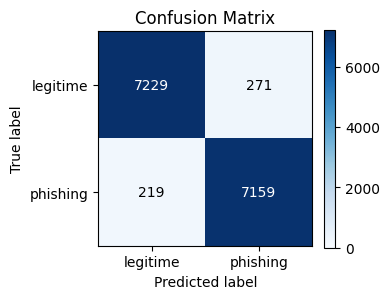

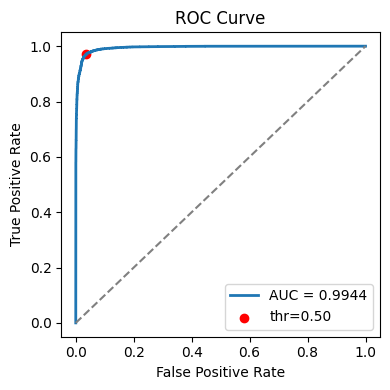

0.9944248757567545

In [55]:
y_true, y_pred, y_scores = [], [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(model.device)
        logits = model(xb).cpu()
        probs = torch.sigmoid(logits)

        y_true.extend(yb.cpu().tolist())
        y_pred.extend((probs >= 0.5).long().tolist())
        y_scores.extend(probs.tolist())

cm = plot_confusion_matrix(y_true, y_pred, normalize=False, labels=['legitime', 'phishing'])
plot_roc_auc(y_true, y_scores)

In [56]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)


def bootstrap_ci(y_true, y_scores, thr=0.5, n_boot=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    metrics = {"acc": [], "prec": [], "rec": [], "f1": [], "auc": []}

    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, ys = y_true[idx], y_scores[idx]
        yp = (ys >= thr).astype(int)

        metrics["acc"].append(accuracy_score(yt, yp))
        metrics["prec"].append(precision_score(yt, yp, zero_division=0))
        metrics["rec"].append(recall_score(yt, yp))
        metrics["f1"].append(f1_score(yt, yp))
        metrics["auc"].append(roc_auc_score(yt, ys))

    ci = {
        m: (np.percentile(vals, 100 * alpha / 2),
            np.percentile(vals, 100 * (1 - alpha / 2)))
        for m, vals in metrics.items()
    }
    return ci

In [57]:
ci95 = bootstrap_ci(y_true, y_scores, thr=0.5)

for m, (lo, hi) in ci95.items():
    print(f"{m.upper():5s} 95% CI: {lo:.4f} – {hi:.4f}")

ACC   95% CI: 0.9640 – 0.9698
PREC  95% CI: 0.9589 – 0.9676
REC   95% CI: 0.9660 – 0.9741
F1    95% CI: 0.9638 – 0.9696
AUC   95% CI: 0.9936 – 0.9952


In [ ]:
import torch
from time import perf_counter

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

# --- 1) pregătește secvența şi lungimea ei ------------------
tok_ids = torch.tensor(X_test[0]).to(device)      # [seq_len]
length  = torch.tensor([tok_ids.numel()]).to(device)  # [1]

tok_ids = tok_ids.unsqueeze(0)   # → [1, seq_len]  (batch=1)

# --- 2) cronometrează inferenţa ------------------------------
N, times = 100, []
with torch.inference_mode():
    for _ in range(N):
        if device == "cuda":
            torch.cuda.synchronize()
        t0 = perf_counter()

        _ = model(tok_ids, length)    # ← PASĂM ŞI lengths

        if device == "cuda":
            torch.cuda.synchronize()
        times.append(perf_counter() - t0)

mean = sum(times)/N*1000
std  = torch.std(torch.tensor(times))*1000
print(f"Medie: {mean:.2f} ms  |  Dev. std: {std:.2f} ms")